In [9]:
import math
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import os
from tinkoff.invest import Client, InstrumentIdType, CandleInterval


In [2]:
TOKEN = "your_token"

C:\Users\Данила\AppData\Local\Temp\ipykernel_10448\762379719.py:28: DeprecatedWarning: options is deprecated. Use `Client.instruments.options_by(...)` method instead
  opts = client.instruments.options().instruments
C:\Users\Данила\AppData\Local\Temp\ipykernel_10448\762379719.py:28: DeprecatedWarning: options is deprecated. Use `Client.instruments.options_by(...)` method instead
  opts = client.instruments.options().instruments


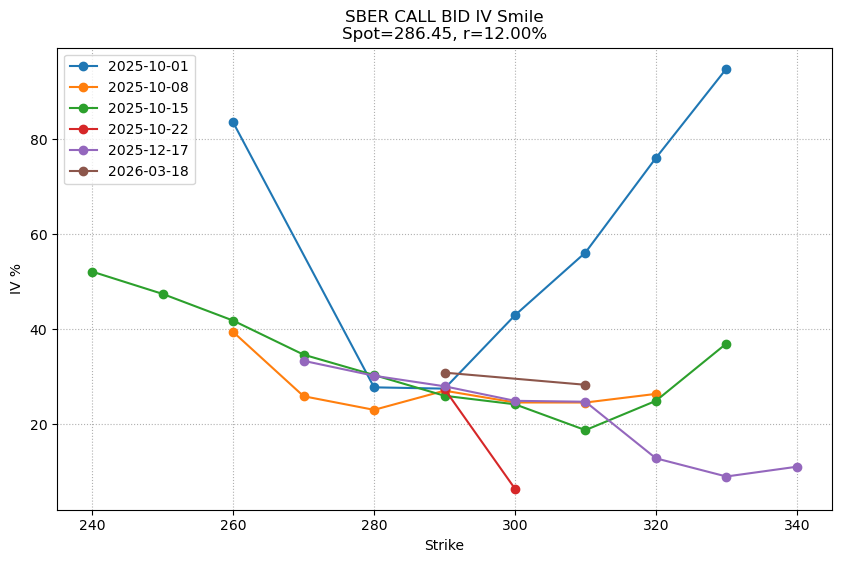

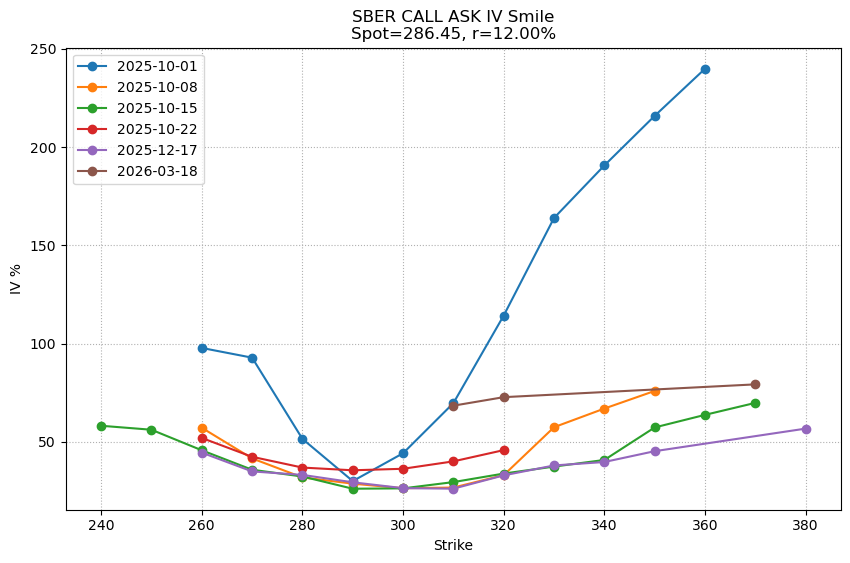

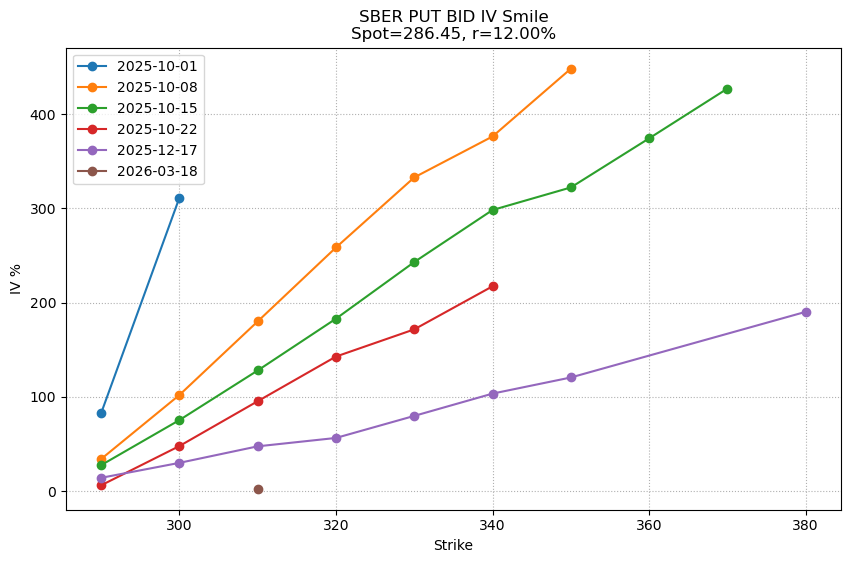

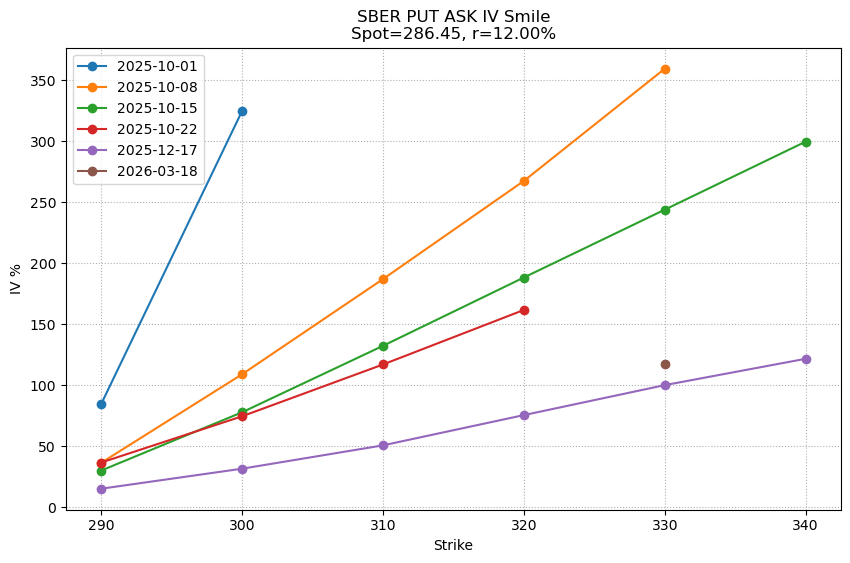

In [11]:
def bs_call_price(S, K, T, r, sigma):
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)


def implied_vol_call(price, S, K, T, r):
    if price is None or price <= 0: 
        return None
    f = lambda sigma: bs_call_price(S, K, T, r, sigma) - price
    try:
        return brentq(f, 1e-6, 5.0)
    except ValueError:
        return None


def q2f(q):
    return q.units + q.nano / 1e9 if q else None


def build_smiles(token, ticker, direction, cutoff=None, r=0.12, depth=5):
    with Client(token) as client:
        shares = client.instruments.shares().instruments
        share_uid = [s.uid for s in shares if s.ticker.upper() == ticker.upper()][0]
        spot = client.market_data.get_last_prices(instrument_id=[share_uid]).last_prices[0].price
        spot = q2f(spot)

        opts = client.instruments.options().instruments
        rows = []
        for o in opts:
            if o.basic_asset.upper() == ticker.upper() and int(o.direction) == direction:
                rows.append({
                    "uid": o.uid,
                    "strike": q2f(o.strike_price),
                    "expiration": pd.to_datetime(str(o.last_trade_date), utc=True)
                })
        df = pd.DataFrame(rows)
        if cutoff:
            cutoff = pd.Timestamp(cutoff, tz="UTC")
            df = df[df["expiration"] <= cutoff]

        recs = []
        for _, row in df.iterrows():
            ob = client.market_data.get_order_book(instrument_id=row["uid"], depth=depth)
            bid = q2f(ob.bids[0].price) if ob.bids else None
            ask = q2f(ob.asks[0].price) if ob.asks else None
            recs.append({"uid": row["uid"], "strike": row["strike"], "expiration": row["expiration"], "bid": bid, "ask": ask})
        quotes = pd.DataFrame(recs)

        today = pd.Timestamp.utcnow().date()
        ivs = []
        for _, r_ in quotes.iterrows():
            T = (r_["expiration"].date() - today).days / 365
            if T <= 0:
                continue
            bid_iv = implied_vol_call(r_["bid"], spot, r_["strike"], T, r) if r_["bid"] else None
            ask_iv = implied_vol_call(r_["ask"], spot, r_["strike"], T, r) if r_["ask"] else None
            ivs.append({"uid": r_["uid"], "expiration": r_["expiration"].date(), "strike": r_["strike"], "bid": r_["bid"], "ask": r_["ask"], "bid_iv": bid_iv, "ask_iv": ask_iv})
        iv = pd.DataFrame(ivs)

        return iv, spot


def plot_smiles(iv, spot, ticker, r, direction, side, out_dir="pics"):
    plt.figure(figsize=(10,6))
    for exp, g in iv.groupby("expiration"):
        g = g.dropna(subset=[f"{side}_iv"]).sort_values("strike")
        if g.empty: continue
        plt.plot(g["strike"], 100*g[f"{side}_iv"], marker="o", label=str(exp))
    name = "CALL" if direction==2 else "PUT"
    plt.xlabel("Strike")
    plt.ylabel("IV %")
    plt.title(f"{ticker} {name} {side.upper()} IV Smile\nSpot={spot:.2f}, r={r:.2%}")
    plt.legend()
    plt.grid(True, linestyle=":")

    os.makedirs(out_dir, exist_ok=True)
    
    fname = os.path.join(out_dir, f"{ticker}_{name}_{side}.png")
    plt.savefig(fname, dpi=150)
    plt.show()


# Пример запуска в Jupyter:
ticker = "SBER"
cutoff = "2026-12-01"
r = 0.12

iv_calls, spot = build_smiles(TOKEN, ticker, direction=2, cutoff=cutoff)
iv_puts, _ = build_smiles(TOKEN, ticker, direction=1, cutoff=cutoff)


for data, direction in [(iv_calls, 2), (iv_puts, 1)]:
    for side in ["bid", "ask"]:
        plot_smiles(data, spot, ticker, r, direction=direction, side=side)


Годовая волатильность: 27.17 %


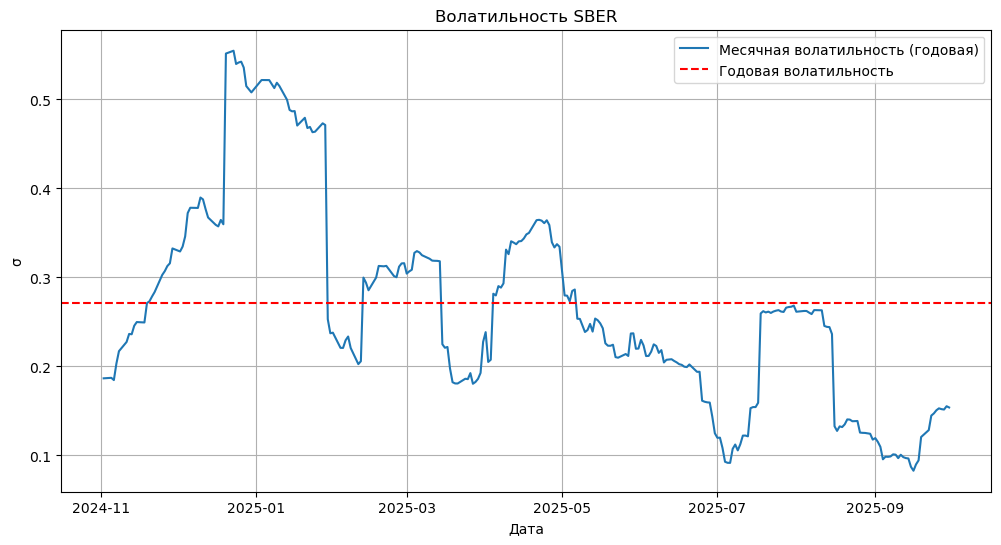

In [16]:
TICKER = "SBER"

with Client(TOKEN) as client:
    share = client.instruments.share_by(
        id_type=InstrumentIdType.INSTRUMENT_ID_TYPE_TICKER,
        id=TICKER,
        class_code="TQBR"
    ).instrument

    end_date = datetime.utcnow()
    start_date = end_date - timedelta(days=365)

    candles = client.market_data.get_candles(
        figi=share.figi,
        from_=start_date,
        to=end_date,
        interval=CandleInterval.CANDLE_INTERVAL_DAY
    ).candles

data = []
for c in candles:
    close = c.close.units + c.close.nano / 1e9
    data.append({"time": pd.to_datetime(c.time), "close": close})
df = pd.DataFrame(data).set_index("time").sort_index()

df["ret"] = np.log(df["close"] / df["close"].shift(1))

year_len = len(df)
month_len = int(len(df)/12)
sigma_year = df["ret"].std() * np.sqrt(year_len)
print("Годовая волатильность:", str(round(100*sigma_year, 2)) + " %")

df["vol_month"] = df["ret"].rolling(month_len).std() * np.sqrt(year_len)

plt.figure(figsize=(12,6))
plt.plot(df.index, df["vol_month"], label="Месячная волатильность (годовая)")
plt.axhline(sigma_year, color="red", linestyle="--", label="Годовая волатильность")
plt.title(f"Волатильность {TICKER}")
plt.xlabel("Дата")
plt.ylabel("σ")
plt.legend()
plt.grid(True)
out_dir="pics"
fname = os.path.join(out_dir, f"{TICKER}_vol.png")
plt.savefig(fname, dpi=150)
plt.show()